In [11]:
# All imports go here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import utils
from risk_model import RiskModel, loss_ratio
from pprint import pprint

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [12]:
# All useful constants go here
TRAIN_FILE = 'train.csv'
TEST_FILE = 'test_final.csv'

TRAIN_SAMPLES = 50000
TEST_SAMPLES = 10000

# Loading data

In [13]:
# Load datasets
train_dfs = {}
test_dfs = {}

train_dfs['main'] = utils.load_dataset(TRAIN_FILE, nrows=TRAIN_SAMPLES)
test_dfs['main'] = utils.load_dataset(TEST_FILE, nrows=TEST_SAMPLES)

utils.check_dataset(train_dfs['main'])
utils.check_dataset(test_dfs['main'], train=False)

In [14]:
train_dfs['prepared'] = utils.prepare_dataset(utils.remove_scores(train_dfs['main']))
test_dfs['prepared'] = utils.prepare_dataset(utils.remove_scores(test_dfs['main']))

In [15]:
# Per policy table
train_dfs['policy'] = train_dfs['prepared'].groupby('contract_number').agg({
    'premium': 'first',
    'premium_wo_term': 'first',
    'claim_amount': 'first',
    'claim_cnt': 'first',
    'is_claim': 'first',
    'term': 'first',
    "experience_year": "mean",
    "car_year": "mean",
    "bonus_malus": "mean",
    "engine_power": "mean",
    "driver_iin": "nunique",
    "car_number": "nunique"
}).rename(columns={
    "driver_iin": "n_drivers",
    "car_number": "n_cars"
}).reset_index()

In [16]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(train_dfs['main'].count())
    print(train_dfs['main'].describe())

contract_number              49966
premium                      49966
premium_wo_term              49966
operation_date               49966
claim_amount                 49966
claim_cnt                    49966
is_claim                     49966
insurer_iin                  49965
driver_iin                   49966
is_individual_person         49966
is_individual_person_name    49966
is_residence                 49966
is_residence_name            49966
region_id                    49966
region_name                  49966
bonus_malus                  49966
age_experience_id            49966
age_experience_name          49966
experience_year              49966
vehicle_type_id              49966
vehicle_type_name            49966
car_age                      49966
ownerkato                    45158
ownerkato_short              49966
model                        49962
mark                         49908
car_number                   49966
car_year                     49966
engine_volume       

# Data analyze

<Axes: xlabel='engine_volume', ylabel='engine_power'>

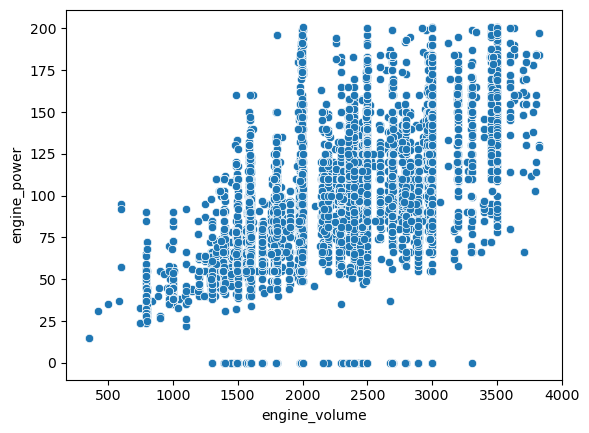

In [17]:
df = train_dfs['main']
df = utils.clean_outliers(df, 'engine_power')
df = utils.clean_outliers(df, 'engine_volume')

# plt.figure(figsize=(30, 10))
# sns.countplot(data=train_dfs['main'], hue='age_experience_name', y='experience_year')
# sns.countplot(data=train_dfs['main'], y='vehicle_type_name')
# plt.xticks(rotation=90)
# sns.countplot(data=train_dfs['main'], x='car_year', hue='car_age')

sns.scatterplot(data=df, x='engine_volume', y='engine_power')

# print(df['operation_date'].min(), df['operation_date'].max())

<Axes: xlabel='claim_cnt', ylabel='percent'>

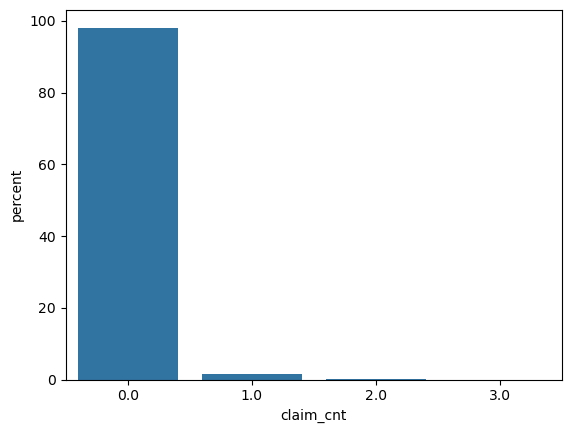

In [18]:
pdf = train_dfs['policy']
pdf['severity'] = np.where(
    pdf["claim_cnt"] > 0,
    pdf["claim_amount"] / pdf["claim_cnt"],
    0
)
pdf["log_severity"] = np.log1p(pdf["severity"])
sns.countplot(pdf, x='claim_cnt', stat='percent')

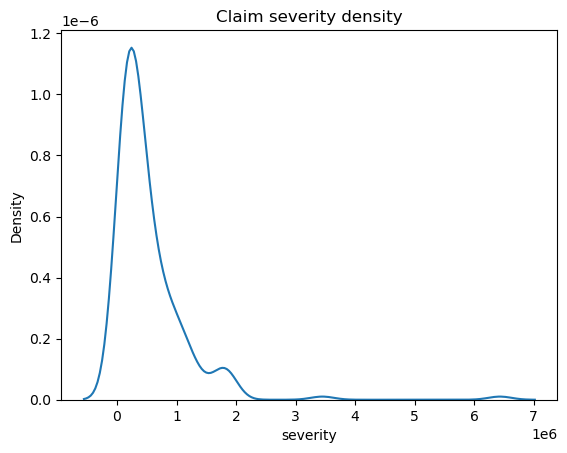

In [19]:
sns.kdeplot(pdf[pdf["severity"] > 0]["severity"])
plt.title("Claim severity density")
plt.show()

# Models

In [20]:
class AlwaysIncreaseModel(RiskModel):
    def __init__(self, data, target_loss_ratio=0.7):
        self.create_from_dataset(data)
        self.target_loss_ratio = target_loss_ratio
    
    def update_premiums(self):
        k = self.old_loss_ratio() / self.target_loss_ratio
        self.new_premiums = self.old_premiums * k

ai_model = AlwaysIncreaseModel(train_dfs['policy'])
ai_model.update()
ai_stats = ai_model.all_stats()
pprint(ai_stats)

{'false_decrease': 0,
 'false_increase': 0.9809162140075951,
 'increased': 1.0,
 'new_loss_ratio': 0.7,
 'old_loss_ratio': 1.1382922308834522}


In [28]:
from sklearn.metrics import classification_report
import catboost

class RegressionModel(RiskModel):
    def __init__(self, data, target_loss_ratio=0.7):
        self.create_from_dataset(data)
        self.target_loss_ratio = target_loss_ratio
        self.X = data[[
            "experience_year",
            "car_year",
            "bonus_malus",
            "engine_power",
            "n_drivers",
            "n_cars"
        ]]
        self.X.fillna(0, inplace=True)
        self.y = data["is_claim"]
        self.model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=67)
        self.scaler = StandardScaler() 

    def train(self):
        X_train, X_valid, y_train, y_valid = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42
        )
        X_train = self.scaler.fit_transform(X_train)
        X_valid = self.scaler.transform(X_valid)
        self.model.fit(X_train, y_train)
        
        scaled_X = self.scaler.transform(self.X)
        self.proba = self.model.predict_proba(scaled_X)[:,1]
        self.p_mean = self.proba.mean()





    def compute_loss_ratio_for_alpha(self, alpha, lower_rel=0.0, upper_mult=3.0):
        rel = 1.0 + alpha * (self.proba - self.p_mean)
        # enforce lower/upper constraints on relativity
        rel = np.clip(rel, lower_rel, upper_mult) 
        new_p = self.old_premiums_wo_term * rel
        lr = loss_ratio(self.claims_amount, new_p)
        return lr, rel

    def search_alpha(self, a_low=-50.0, a_high=200.0, iters=60):
        for _ in range(iters):
            a_mid = 0.5 * (a_low + a_high)
            lr_mid, _ = self.compute_loss_ratio_for_alpha(a_mid)
            if lr_mid > self.target_loss_ratio:
                a_low = a_mid
            else:
                a_high = a_mid

        return 0.5*(a_low + a_high)
    
    def update_premiums(self):
        alpha = self.search_alpha()
        _, rel = self.compute_loss_ratio_for_alpha(alpha)
        self.new_premiums = self.old_premiums * rel

reg_model = RegressionModel(train_dfs['policy'])
reg_model.train()
reg_model.update()
reg_stats = reg_model.all_stats()
pprint(reg_stats)

{'false_decrease': 0.013265569816521664,
 'false_increase': 0.9735697193822058,
 'increased': 0.4419554871893477,
 'new_loss_ratio': 0.7613818984248436,
 'old_loss_ratio': 1.1382922308834522}


C:\Users\askar\AppData\Local\Temp\ipykernel_30548\165542196.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.X.fillna(0, inplace=True)


In [26]:
reg_model.p_mean

0.4828666297255298

In [49]:
from catboost import CatBoostClassifier
from sklearn.utils import compute_class_weight




class CatModel(RegressionModel):
    def __init__(self, data, target_loss_ratio=0.7):
        super().__init__(data, target_loss_ratio)
        pos_class = sum(self.y == 0)
        neg_class = sum(self.y == 1)
        scale_pos = pos_class / neg_class
        weights = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(self.y),
            y=self.y
        )

        self.model = CatBoostClassifier(iterations=7000, learning_rate=0.0007, random_state=42, class_weights=weights)
        


    def train(self):
        X_train, X_valid, y_train, y_valid = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42
        )
        
       # X_train = self.scaler.fit_transform(X_train)
        #X_valid = self.scaler.transform(X_valid)
        self.model.fit(X_train, y_train)
        
        #scaled_X = self.scaler.transform(self.X)
        self.proba = self.model.predict_proba(self.X)[:,1]
        self.p_mean = self.proba.mean()





    def compute_loss_ratio_for_alpha(self, alpha, lower_rel=0.0, upper_mult=3.0):
        rel = 1.0 + alpha * (self.proba - self.p_mean)
        # enforce lower/upper constraints on relativity
        rel = np.clip(rel, lower_rel, upper_mult) 
        new_p = self.old_premiums_wo_term * rel
        lr = loss_ratio(self.claims_amount, new_p)
        return lr, rel

    def search_alpha(self, a_low=-50.0, a_high=200.0, iters=60):
        for _ in range(iters):
            a_mid = 0.5 * (a_low + a_high)
            lr_mid, _ = self.compute_loss_ratio_for_alpha(a_mid)
            if lr_mid > self.target_loss_ratio:
                a_low = a_mid
            else:
                a_high = a_mid

        return 0.5*(a_low + a_high)
    
    def update_premiums(self):
        alpha = self.search_alpha()
        _, rel = self.compute_loss_ratio_for_alpha(alpha)
        self.new_premiums = self.old_premiums * rel

cat_model = CatModel(train_dfs['policy'])
cat_model.train()
cat_model.update()
cat_stats = cat_model.all_stats()
pprint(cat_stats)

C:\Users\askar\AppData\Local\Temp\ipykernel_30548\165542196.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.X.fillna(0, inplace=True)


0:	learn: 0.6930983	total: 6.99ms	remaining: 48.9s
1:	learn: 0.6930394	total: 13.6ms	remaining: 47.6s
2:	learn: 0.6929984	total: 20.1ms	remaining: 46.8s
3:	learn: 0.6929548	total: 25.6ms	remaining: 44.8s
4:	learn: 0.6929152	total: 32.2ms	remaining: 45.1s
5:	learn: 0.6928727	total: 37.9ms	remaining: 44.2s
6:	learn: 0.6928004	total: 44.4ms	remaining: 44.3s
7:	learn: 0.6927516	total: 50.5ms	remaining: 44.2s
8:	learn: 0.6927000	total: 56.9ms	remaining: 44.2s
9:	learn: 0.6926637	total: 63ms	remaining: 44s
10:	learn: 0.6926286	total: 70ms	remaining: 44.5s
11:	learn: 0.6925725	total: 76.6ms	remaining: 44.6s
12:	learn: 0.6925261	total: 82.5ms	remaining: 44.3s
13:	learn: 0.6924707	total: 88.7ms	remaining: 44.3s
14:	learn: 0.6924290	total: 94.8ms	remaining: 44.2s
15:	learn: 0.6923715	total: 101ms	remaining: 44.2s
16:	learn: 0.6923278	total: 108ms	remaining: 44.5s
17:	learn: 0.6922796	total: 114ms	remaining: 44.3s
18:	learn: 0.6922287	total: 120ms	remaining: 44.1s
19:	learn: 0.6921973	total: 126m

In [50]:
cat_model.p_mean

0.41526289779075165